# Pipeline completo — Base 04: Clima de Jena (2009–2016)

**Objetivo:** prever a temperatura média diária (`T (degC)`) do dia seguinte.

A base original registra medições meteorológicas a cada 10 minutos. O fluxo abaixo:

1. localiza e audita o CSV;
2. trata duplicatas, valores sentinela e direção do vento;
3. agrega as observações para frequência diária e regulariza lacunas sem usar dados futuros;
4. explora a série e compara sazonalidades com STL;
5. cria atributos disponíveis até a origem da previsão, com calendário da data-alvo;
6. separa ajuste, seleção de modelo e teste final em ordem cronológica;
7. seleciona hiperparâmetros somente no período de desenvolvimento;
8. executa previsões _walk-forward_ com SARIMAX, Holt-Winters, Random Forest e SVR;
9. compara os modelos com uma referência de persistência no teste final;
10. diagnostica resíduos, estima importância das variáveis e exporta os artefatos.

A origem `t` usa informações conhecidas até o fim do dia `t`; o alvo é a temperatura média observada de `t+1`. Dias sem observações não entram como alvos de treino, seleção ou teste.


## 1. Configuração do experimento

A sazonalidade semanal é usada nos modelos clássicos para manter o ajuste computacionalmente viável. A sazonalidade anual continua representada na análise STL e nas variáveis cíclicas de calendário.


In [4]:
import os
import warnings
from pathlib import Path
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.base import clone
from sklearn.compose import TransformedTargetRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.statespace.sarimax import SARIMAX

warnings.filterwarnings('ignore')
os.environ['PYTHONWARNINGS'] = 'ignore'
sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 50)

BASE_ID = 'base_04'
TARGET = 'T (degC)'
DATETIME_COL = 'Date Time'
INPUT_FILENAME = '../data/raw/base_04/jena_climate_2009_2016.csv'

FREQ = 'D'
HORIZON = 1
EXPECTED_OBSERVATIONS_PER_DAY = 144
LOW_COVERAGE_THRESHOLD = 0.80
MODEL_SEASONAL_PERIOD = 7
STL_PERIODS = {
    'Semanal': 7,
    'Mensal': 30,
    'Trimestral': 91,
    'Semestral': 182,
    'Anual': 365,
}
TRAIN_RATIO = 0.70
TEST_RATIO = 0.30
VALIDATION_SIZE = 60
TUNING_VALIDATION_SIZE = 60

RANDOM_STATE = 42
LJUNG_BOX_LAG = 10
HW_REFIT_EVERY = 7
ML_REFIT_EVERY = 30
IMPORTANCE_EVAL_SIZE = 8
IMPORTANCE_REPEATS = 2
IMPORTANCE_WINDOW = 365

cwd = Path.cwd().resolve()
candidates = [cwd / INPUT_FILENAME, cwd.parent / INPUT_FILENAME]
DATA_PATH = next((path for path in candidates if path.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError(
        f'Arquivo {INPUT_FILENAME!r} não encontrado em {cwd} nem em {cwd.parent}.'
    )

ROOT = DATA_PATH.parent
OUTPUT_ROOT = ROOT / 'outputs' / BASE_ID
PROCESSED_PATH = OUTPUT_ROOT / 'processed' / f'{BASE_ID}_daily.csv'
PREDICTIONS_PATH = OUTPUT_ROOT / 'predictions' / f'{BASE_ID}_predictions.csv'
METRICS_PATH = OUTPUT_ROOT / 'metrics' / f'{BASE_ID}_metrics.csv'
SELECTION_PATH = OUTPUT_ROOT / 'metrics' / f'{BASE_ID}_selection.csv'
SARIMAX_TUNING_PATH = OUTPUT_ROOT / 'metrics' / f'{BASE_ID}_sarimax_tuning.csv'
HW_TUNING_PATH = OUTPUT_ROOT / 'metrics' / f'{BASE_ID}_holt_winters_tuning.csv'
SEASONALITY_PATH = OUTPUT_ROOT / 'metrics' / f'{BASE_ID}_seasonality.csv'
RESIDUALS_PATH = OUTPUT_ROOT / 'residuals' / f'{BASE_ID}_residuals.csv'
IMPORTANCE_PATH = OUTPUT_ROOT / 'feature_importance' / f'{BASE_ID}_feature_importance.csv'
FIGURES_DIR = OUTPUT_ROOT / 'figures'

for directory in {
    PROCESSED_PATH.parent,
    PREDICTIONS_PATH.parent,
    METRICS_PATH.parent,
    SELECTION_PATH.parent,
    SARIMAX_TUNING_PATH.parent,
    HW_TUNING_PATH.parent,
    SEASONALITY_PATH.parent,
    RESIDUALS_PATH.parent,
    IMPORTANCE_PATH.parent,
    FIGURES_DIR,
}:
    directory.mkdir(parents=True, exist_ok=True)

print('Arquivo de entrada:', DATA_PATH)
print('Pasta de saída:', OUTPUT_ROOT)

Arquivo de entrada: C:\Users\igorpereira-ieg\OneDrive - Instituto Germinare\Área de Trabalho\MODO DIFICIL\SERIES TEMPORAIS\Daniel Max\modelos-svr\notebooks\..\data\raw\base_04\jena_climate_2009_2016.csv
Pasta de saída: C:\Users\igorpereira-ieg\OneDrive - Instituto Germinare\Área de Trabalho\MODO DIFICIL\SERIES TEMPORAIS\Daniel Max\modelos-svr\notebooks\..\data\raw\base_04\outputs\base_04


## 2. Carregamento e auditoria temporal

A leitura exige as 15 colunas documentadas da base. Datas são interpretadas no formato dia–mês–ano. A auditoria registra intervalo temporal, ordem original, duplicatas, ausências e valores sentinela de vento (`-9999`).


In [5]:
required_columns = [
    'Date Time', 'p (mbar)', 'T (degC)', 'Tpot (K)', 'Tdew (degC)',
    'rh (%)', 'VPmax (mbar)', 'VPact (mbar)', 'VPdef (mbar)',
    'sh (g/kg)', 'H2OC (mmol/mol)', 'rho (g/m**3)', 'wv (m/s)',
    'max. wv (m/s)', 'wd (deg)',
]
raw = pd.read_csv(DATA_PATH, low_memory=False)

missing_columns = sorted(set(required_columns) - set(raw.columns))
if missing_columns:
    raise ValueError(f'Colunas ausentes: {missing_columns}')

raw[DATETIME_COL] = pd.to_datetime(
    raw[DATETIME_COL],
    format='%d.%m.%Y %H:%M:%S',
    errors='coerce',
)
if raw[DATETIME_COL].isna().any():
    raise ValueError('Há datas inválidas após a conversão de Date Time.')

numeric_columns = [column for column in required_columns if column != DATETIME_COL]
raw[numeric_columns] = raw[numeric_columns].apply(pd.to_numeric, errors='coerce')

if raw[DATETIME_COL].is_monotonic_increasing:
    original_order = 'crescente'
elif raw[DATETIME_COL].is_monotonic_decreasing:
    original_order = 'decrescente'
else:
    original_order = 'irregular'

wind_columns = ['wv (m/s)', 'max. wv (m/s)']
sentinel_count = int((raw[wind_columns] <= -999).sum().sum())

audit = pd.DataFrame({
    'observacoes': [len(raw)],
    'inicio': [raw[DATETIME_COL].min()],
    'fim': [raw[DATETIME_COL].max()],
    'duplicatas_timestamp': [raw[DATETIME_COL].duplicated().sum()],
    'nulos_totais': [raw[required_columns].isna().sum().sum()],
    'sentinelas_vento': [sentinel_count],
    'ordem_original': [original_order],
})

display(audit, raw.head(3))

,observacoes,inicio,fim,duplicatas_timestamp,nulos_totais,sentinelas_vento,ordem_original
0,420551,2009-01-01 00:10:00,2017-01-01,327,0,38,irregular


,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
0,2009-01-01 00:10:00,996.52,-8.02,265.40,-8.90,93.3,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.3
1,2009-01-01 00:20:00,996.57,-8.41,265.01,-9.28,93.4,3.23,3.02,0.21,1.89,3.03,1309.80,0.72,1.50,136.1
2,2009-01-01 00:30:00,996.53,-8.51,264.91,-9.31,93.9,3.21,3.01,0.20,1.88,3.02,1310.24,0.19,0.63,171.6


## 3. Limpeza, agregação e regularização diária

- timestamps duplicados mantêm o último registro;
- valores de vento menores ou iguais a `-999` viram ausentes antes da agregação;
- direção do vento é convertida em seno e cosseno, evitando a média incorreta entre 359° e 1°;
- variáveis meteorológicas usam média diária, exceto rajada máxima, que usa o máximo;
- o registro isolado de 01/01/2017 é removido porque não representa um dia completo;
- dias totalmente ausentes recebem o último valor conhecido (`ffill`), sem consultar o futuro;
- cobertura e dias imputados permanecem explícitos para auditoria e modelagem.


In [3]:
raw_clean = (
    raw.sort_values(DATETIME_COL)
    .drop_duplicates(DATETIME_COL, keep='last')
    .copy()
)

for column in wind_columns:
    raw_clean.loc[raw_clean[column] <= -999, column] = np.nan

wind_radians = np.deg2rad(raw_clean['wd (deg)'] % 360)
raw_clean['wind_dir_sin'] = np.sin(wind_radians)
raw_clean['wind_dir_cos'] = np.cos(wind_radians)

mean_columns = [
    'p (mbar)', 'T (degC)', 'Tpot (K)', 'Tdew (degC)', 'rh (%)',
    'VPmax (mbar)', 'VPact (mbar)', 'VPdef (mbar)', 'sh (g/kg)',
    'H2OC (mmol/mol)', 'rho (g/m**3)', 'wv (m/s)',
    'wind_dir_sin', 'wind_dir_cos',
]
aggregation = {column: 'mean' for column in mean_columns}
aggregation['max. wv (m/s)'] = 'max'

indexed = raw_clean.set_index(DATETIME_COL)
data = indexed.resample(FREQ).agg(aggregation)
observations_per_day = indexed[TARGET].resample(FREQ).count()

last_timestamp = raw_clean[DATETIME_COL].max()
if last_timestamp.time() < pd.Timestamp('23:50:00').time():
    incomplete_last_day = last_timestamp.normalize()
    data = data.loc[data.index < incomplete_last_day]
    observations_per_day = observations_per_day.loc[
        observations_per_day.index < incomplete_last_day
    ]

daily_index = pd.date_range(
    start=data.index.min(),
    end=data.index.max(),
    freq=FREQ,
    name='data',
)
data = data.reindex(daily_index)
observations_per_day = observations_per_day.reindex(daily_index, fill_value=0)

data['observacoes_10min'] = observations_per_day.astype(int)
data['cobertura_dia'] = (
    data['observacoes_10min'] / EXPECTED_OBSERVATIONS_PER_DAY
).clip(0, 1)
data['imputado'] = data['observacoes_10min'].eq(0)
data['baixa_cobertura'] = data['cobertura_dia'].lt(LOW_COVERAGE_THRESHOLD)

model_daily_columns = list(aggregation)
data[model_daily_columns] = data[model_daily_columns].ffill()
data['wind_dir_media_deg'] = (
    np.degrees(np.arctan2(data['wind_dir_sin'], data['wind_dir_cos'])) + 360
) % 360

if data[model_daily_columns].isna().any().any():
    missing = data[model_daily_columns].isna().sum()
    raise ValueError(f'Persistiram ausências após a regularização:\n{missing[missing > 0]}')

assert data.index.is_monotonic_increasing
assert data.index.is_unique
assert data.index.to_series().diff().dropna().eq(pd.Timedelta(days=1)).all()

quality_summary = pd.DataFrame({
    'dias': [len(data)],
    'dias_imputados': [int(data['imputado'].sum())],
    'dias_baixa_cobertura': [int(data['baixa_cobertura'].sum())],
    'cobertura_media': [data['cobertura_dia'].mean()],
    'inicio': [data.index.min()],
    'fim': [data.index.max()],
})
display(quality_summary, data.head())

,dias,dias_imputados,dias_baixa_cobertura,cobertura_media,inicio,fim
0,2922,2,6,0.998705,2009-01-01,2016-12-31


,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),wind_dir_sin,wind_dir_cos,max. wv (m/s),observacoes_10min,cobertura_dia,imputado,baixa_cobertura,wind_dir_media_deg
data,,,,,,,,,,,,,,,,,,,,
2009-01-01,999.145594,-6.810629,266.414545,-8.015594,91.086014,3.691119,3.355524,0.335315,2.091049,3.357832,1305.178252,0.778601,0.057463,-0.597172,3.63,143,0.993056,False,False,174.503654
2009-01-02,999.600625,-3.728194,269.463194,-4.824861,92.086806,4.640069,4.267292,0.373056,2.659792,4.268750,1290.353194,1.419514,0.222015,-0.026512,6.13,144,1.000000,False,False,96.809693
2009-01-03,998.548611,-5.271736,268.002292,-9.015833,76.458056,4.184792,3.107708,1.077014,1.937778,3.111944,1297.117014,1.250903,-0.256563,-0.546490,4.88,144,1.000000,False,False,205.148831
2009-01-04,988.510694,-1.375208,272.685347,-2.897014,89.417361,5.524306,4.938958,0.584861,3.114028,4.997014,1264.634514,1.720417,-0.512657,-0.681863,7.13,144,1.000000,False,False,216.937565
2009-01-05,990.405694,-4.867153,269.039306,-6.797292,86.260417,4.362708,3.806736,0.555625,2.397014,3.847778,1284.372778,3.800278,-0.114762,0.543043,10.88,144,1.000000,False,False,348.067154


## 4. Análise exploratória

A estatística descritiva é calculada sobre a série diária. Os gráficos mostram temperatura, tendência móvel, velocidade do vento e cobertura das observações originais.


,count,mean,std,min,25%,50%,75%,max
T (degC),2922.0,9.442294,7.833958,-16.457292,3.814010,9.706528,15.420503,29.375347
p (mbar),2922.0,989.218985,8.092123,948.995972,984.361267,989.530903,994.429635,1013.957569
Tdew (degC),2922.0,4.957182,6.577954,-19.387222,0.365052,5.294931,9.954236,20.185486
rh (%),2922.0,76.048140,11.383079,37.580347,67.688542,77.000868,84.569427,100.000000
wv (m/s),2922.0,2.127882,0.969021,0.000000,1.448750,1.903090,2.586753,7.644514
max. wv (m/s),2922.0,7.973751,2.943993,0.000000,5.880000,7.490000,9.570000,23.500000
cobertura_dia,2922.0,0.998705,0.031025,0.000000,1.000000,1.000000,1.000000,1.000000


,correlacao_com_temperatura
Tpot (K),0.996548
VPmax (mbar),0.961356
rho (g/m**3),-0.960806
Tdew (degC),0.948357
VPact (mbar),0.921790
H2OC (mmol/mol),0.920978
sh (g/kg),0.920574
VPdef (mbar),0.804933
rh (%),-0.529506
max. wv (m/s),0.154675


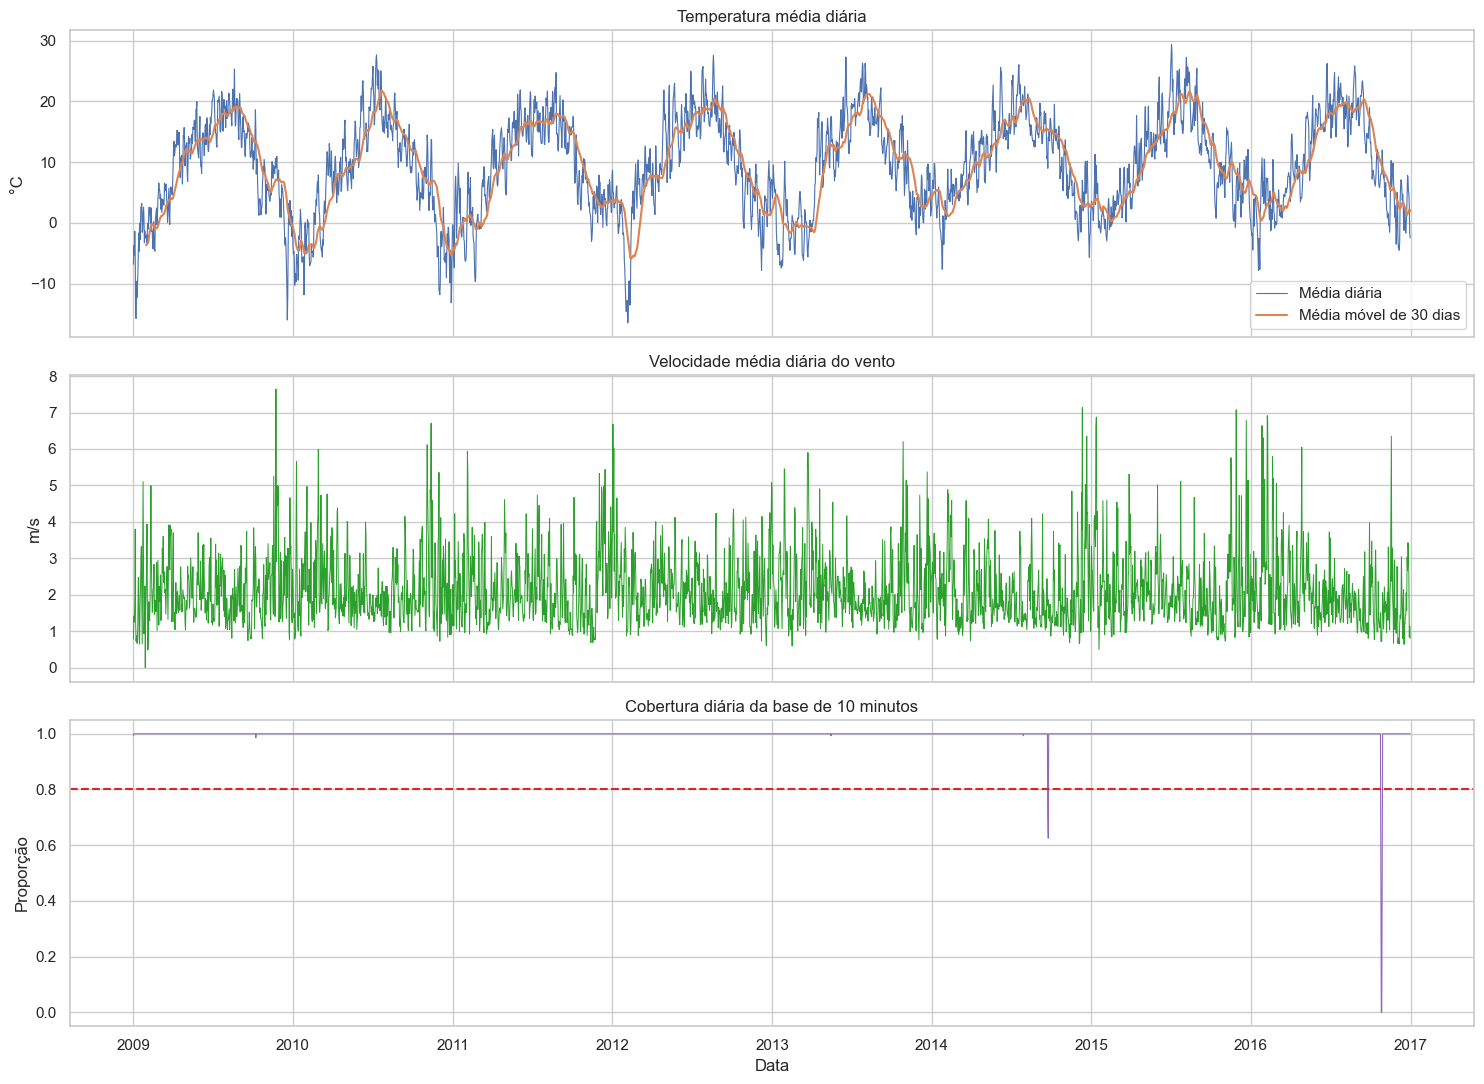

In [4]:
descriptive_columns = [
    'T (degC)', 'p (mbar)', 'Tdew (degC)', 'rh (%)',
    'wv (m/s)', 'max. wv (m/s)', 'cobertura_dia',
]
display(data[descriptive_columns].describe().T)

correlations = (
    data[model_daily_columns]
    .corr()[TARGET]
    .drop(TARGET)
    .sort_values(key=np.abs, ascending=False)
    .to_frame('correlacao_com_temperatura')
)
display(correlations)

fig, axes = plt.subplots(3, 1, figsize=(15, 11), sharex=True)
axes[0].plot(data.index, data[TARGET], linewidth=0.8, label='Média diária')
axes[0].plot(
    data.index,
    data[TARGET].rolling(30).mean(),
    linewidth=1.5,
    label='Média móvel de 30 dias',
)
axes[0].set(title='Temperatura média diária', ylabel='°C')
axes[0].legend()

axes[1].plot(data.index, data['wv (m/s)'], linewidth=0.7, color='tab:green')
axes[1].set(title='Velocidade média diária do vento', ylabel='m/s')

axes[2].plot(data.index, data['cobertura_dia'], linewidth=0.8, color='tab:purple')
axes[2].axhline(LOW_COVERAGE_THRESHOLD, color='tab:red', linestyle='--')
axes[2].set(title='Cobertura diária da base de 10 minutos', ylabel='Proporção', xlabel='Data')

fig.tight_layout()
fig.savefig(FIGURES_DIR / '01_eda.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Decomposição STL e força sazonal

Cada periodicidade é ajustada separadamente. A força sazonal é calculada por
`max(0, 1 - Var(resíduo) / Var(sazonal + resíduo))`. A comparação é diagnóstica e não escolhe automaticamente a sazonalidade dos modelos.


,periodicidade,periodo_dias,forca_sazonal
0,Semanal,7,0.117633
1,Mensal,30,0.196620
2,Trimestral,91,0.143810
3,Semestral,182,0.046949
4,Anual,365,0.803017


Maior força sazonal: Anual (365 dias) — 0.803


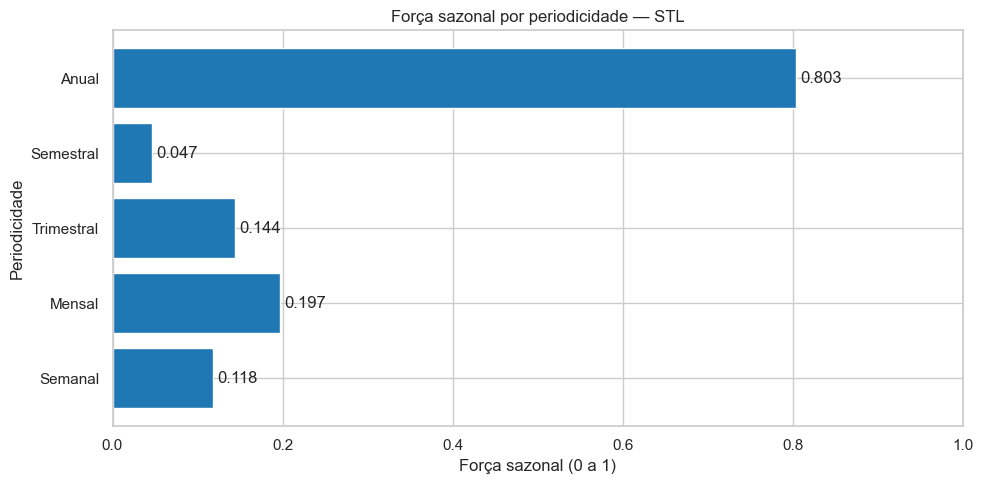

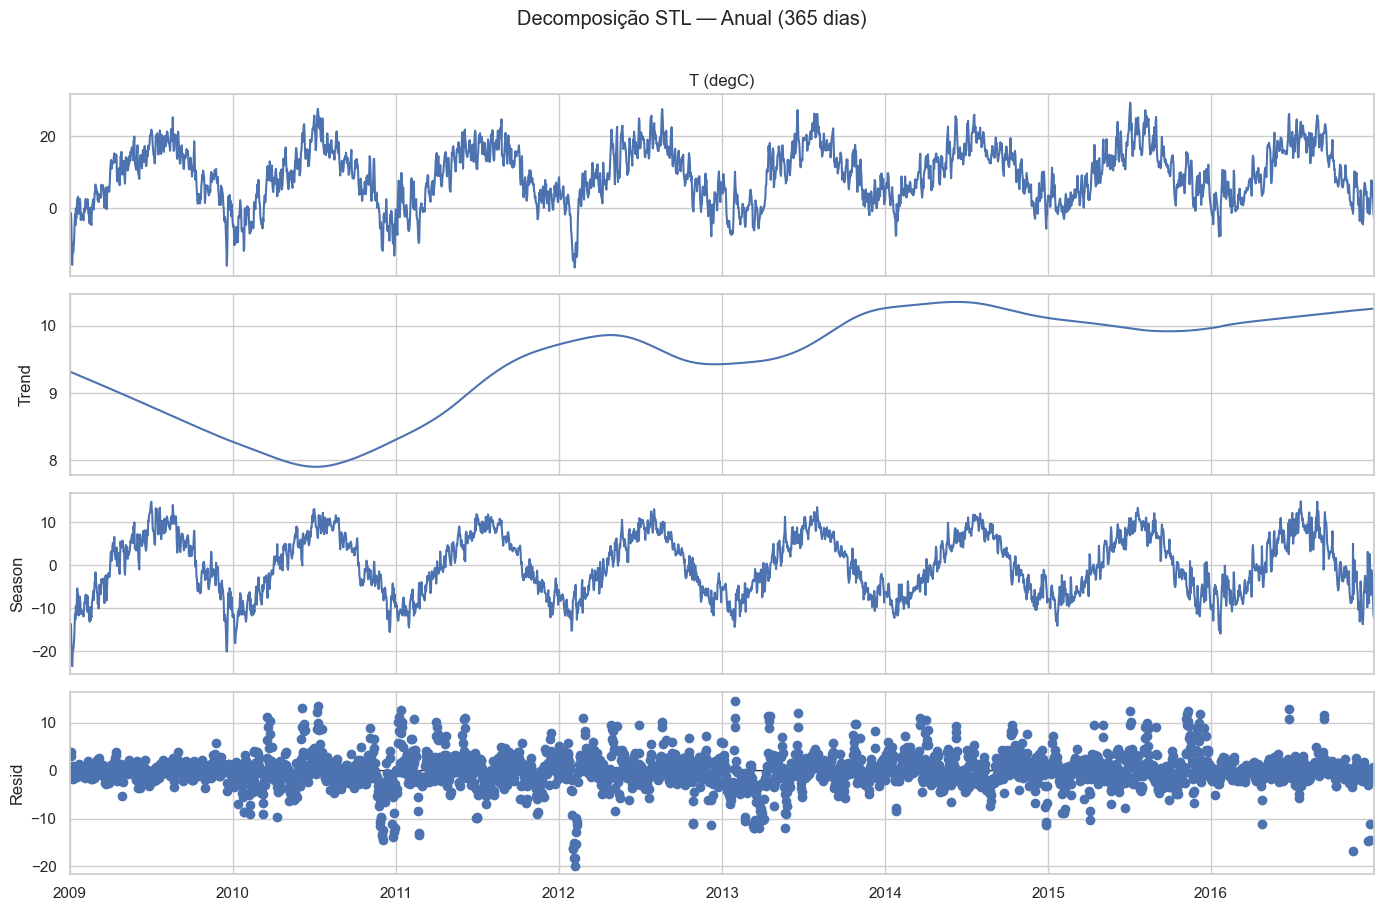

In [5]:
def fit_stl_and_measure_strength(series, period):
    """Ajusta uma STL e retorna o resultado e sua força sazonal."""
    result = STL(series, period=period, robust=True).fit()
    seasonal_plus_residual = result.seasonal + result.resid
    denominator = np.var(seasonal_plus_residual)
    strength = 0.0 if denominator == 0 else max(
        0.0,
        1 - np.var(result.resid) / denominator,
    )
    return result, float(strength)


stl_results = {}
seasonality_rows = []
for period_name, period_days in STL_PERIODS.items():
    result, strength = fit_stl_and_measure_strength(
        data[TARGET],
        period=period_days,
    )
    stl_results[period_days] = result
    seasonality_rows.append({
        'periodicidade': period_name,
        'periodo_dias': period_days,
        'forca_sazonal': strength,
    })

seasonality_comparison = (
    pd.DataFrame(seasonality_rows)
    .sort_values('periodo_dias', ignore_index=True)
)
best_period_row = seasonality_comparison.loc[
    seasonality_comparison['forca_sazonal'].idxmax()
]
best_period_days = int(best_period_row['periodo_dias'])
best_period_name = best_period_row['periodicidade']
best_stl_result = stl_results[best_period_days]

display(seasonality_comparison)
print(
    f'Maior força sazonal: {best_period_name} ({best_period_days} dias) — '
    f'{best_period_row.forca_sazonal:.3f}'
)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(
    seasonality_comparison['periodicidade'],
    seasonality_comparison['forca_sazonal'],
    color='tab:blue',
)
ax.bar_label(bars, fmt='%.3f', padding=3)
ax.set(
    title='Força sazonal por periodicidade — STL',
    xlabel='Força sazonal (0 a 1)',
    ylabel='Periodicidade',
    xlim=(0, 1),
)
fig.tight_layout()
fig.savefig(FIGURES_DIR / '02_stl_forcas.png', dpi=150, bbox_inches='tight')
plt.show()

fig = best_stl_result.plot()
fig.set_size_inches(14, 9)
fig.suptitle(
    f'Decomposição STL — {best_period_name} ({best_period_days} dias)',
    y=1.01,
)
fig.tight_layout()
fig.savefig(FIGURES_DIR / '02_stl_melhor_periodo.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Criação de features sem vazamento

Cada linha representa uma origem `t`. O alvo é a temperatura média de `t+1`. Todas as variáveis usam somente medições e calendários disponíveis até o fim de `t`:

- temperatura de hoje e defasagens de até 365 dias;
- diferenças e estatísticas móveis retrospectivas;
- condições meteorológicas observadas no próprio dia;
- direção do vento em representação circular;
- ciclos semanal e anual;
- indicadores de cobertura e imputação.


In [17]:
def build_features(frame):
    """Transforma a série diária em tabela supervisionada para prever t+1."""
    temperature = frame[TARGET]
    features = pd.DataFrame(index=frame.index)

    features['temperatura_hoje'] = temperature
    for lag in [1, 2, 3, 7, 14, 30, 365]:
        features[f'temperatura_lag_{lag}'] = temperature.shift(lag)

    features['variacao_1d'] = temperature.diff(1)
    features['variacao_7d'] = temperature.diff(7)
    for window in [7, 30, 90]:
        rolling = temperature.rolling(window)
        features[f'temperatura_media_{window}d'] = rolling.mean()
        features[f'temperatura_desvio_{window}d'] = rolling.std()

    weather_features = {
        'p (mbar)': 'pressao',
        'Tdew (degC)': 'ponto_orvalho',
        'rh (%)': 'umidade_relativa',
        'VPdef (mbar)': 'deficit_pressao_vapor',
        'sh (g/kg)': 'umidade_especifica',
        'rho (g/m**3)': 'densidade_ar',
        'wv (m/s)': 'vento_medio',
        'max. wv (m/s)': 'vento_maximo',
        'wind_dir_sin': 'direcao_vento_sin',
        'wind_dir_cos': 'direcao_vento_cos',
        'cobertura_dia': 'cobertura_dia',
    }
    for source_column, feature_name in weather_features.items():
        features[feature_name] = frame[source_column]

    target_dates = frame.index.to_series().shift(-HORIZON)
    day_of_week = target_dates.dt.dayofweek
    features['dia_semana_sin'] = np.sin(2 * np.pi * day_of_week / 7)
    features['dia_semana_cos'] = np.cos(2 * np.pi * day_of_week / 7)

    day_of_year = target_dates.dt.dayofyear
    days_in_year = np.where(target_dates.dt.is_leap_year, 366, 365)
    for harmonic in [1, 2, 3]:
        angle = 2 * np.pi * harmonic * day_of_year / days_in_year
        features[f'dia_ano_sin_{harmonic}'] = np.sin(angle)
        features[f'dia_ano_cos_{harmonic}'] = np.cos(angle)

    features['dia_imputado'] = frame['imputado'].astype(int)
    features['baixa_cobertura'] = frame['baixa_cobertura'].astype(int)
    features['target'] = temperature.shift(-HORIZON)
    features['target_date'] = target_dates
    features['target_observed'] = (
        frame['observacoes_10min'].shift(-HORIZON).fillna(0).gt(0)
    )

    features = features.replace([np.inf, -np.inf], np.nan).dropna()
    return features.loc[features['target_observed']].drop(columns='target_observed')


supervised = build_features(data)
feature_columns = [
    column for column in supervised.columns
    if column not in ['target', 'target_date']
]
X = supervised[feature_columns]
y_ml = supervised['target']
target_dates_ml = pd.DatetimeIndex(supervised['target_date'])

print(f'{len(supervised):,} exemplos com alvo observado e {len(feature_columns)} features')
display(supervised.head(3))

2,554 exemplos com alvo observado e 37 features


,temperatura_hoje,temperatura_lag_1,temperatura_lag_2,temperatura_lag_3,temperatura_lag_7,temperatura_lag_14,temperatura_lag_30,temperatura_lag_365,variacao_1d,variacao_7d,temperatura_media_7d,temperatura_desvio_7d,temperatura_media_30d,temperatura_desvio_30d,temperatura_media_90d,temperatura_desvio_90d,pressao,ponto_orvalho,umidade_relativa,deficit_pressao_vapor,umidade_especifica,densidade_ar,vento_medio,vento_maximo,direcao_vento_sin,direcao_vento_cos,cobertura_dia,dia_semana_sin,dia_semana_cos,dia_ano_sin_1,dia_ano_cos_1,dia_ano_sin_2,dia_ano_cos_2,dia_ano_sin_3,dia_ano_cos_3,dia_imputado,baixa_cobertura,target,target_date
data,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2010-01-01,-3.819236,-1.282292,1.119931,-2.211875,3.690417,-10.736250,0.947431,-6.810629,-2.536944,-7.509653,-0.389087,2.223913,-0.785713,5.311358,4.434882,5.604458,969.639583,-4.513333,94.889583,0.234931,2.807153,1251.977847,2.408750,6.13,0.295335,0.737485,1.0,-0.974928,-0.222521,0.034422,0.999407,0.068802,0.997630,0.103102,0.994671,0,0,-5.110556,2010-01-02
2010-01-02,-5.110556,-3.819236,-1.282292,1.119931,2.002986,-15.984931,3.923403,-3.728194,-1.291319,-7.113542,-1.405308,2.550034,-1.086845,5.291220,4.247406,5.638698,985.276042,-6.271875,91.503472,0.358819,2.432083,1278.671528,1.711944,5.81,-0.763245,-0.395239,1.0,-0.781831,0.623490,0.051620,0.998667,0.103102,0.994671,0.154309,0.988023,0,0,-4.702222,2010-01-03
2010-01-03,-4.702222,-5.110556,-3.819236,-1.282292,-0.545069,-12.193194,2.817153,-5.271736,0.408333,-4.157153,-1.999187,2.789171,-1.337491,5.277991,4.080074,5.678650,990.545556,-5.694861,92.744444,0.320278,2.530833,1283.468125,1.364514,5.29,0.058750,-0.376315,1.0,0.000000,1.000000,0.068802,0.997630,0.137279,0.990532,0.205104,0.978740,0,0,-6.132569,2010-01-04


## 7. Divisão temporal e protocolo walk-forward

Os exemplos supervisionados são separados em ordem cronológica. Dentro dos 70% iniciais, os 60 exemplos finais formam uma janela exclusiva para escolher o modelo; os dados anteriores são usados para ajuste de hiperparâmetros. Os 30% finais ficam reservados à avaliação final. SARIMAX e Holt-Winters usam ainda os 60 dias anteriores à janela de seleção para ajuste interno.

No teste, cada previsão é feita antes de incorporar o valor real do dia previsto. Holt-Winters é atualizado semanalmente; RF e SVR são reestimados a cada 30 origens para limitar o custo computacional.


In [18]:
series = data[TARGET].astype(float).asfreq(FREQ)

if not np.isclose(TRAIN_RATIO + TEST_RATIO, 1.0):
    raise ValueError('As proporções de treino e teste devem somar 1.')

TEST_SIZE = int(np.ceil(len(X) * TEST_RATIO))
train_size = len(X) - TEST_SIZE
selection_start = train_size - VALIDATION_SIZE
if selection_start <= TUNING_VALIDATION_SIZE:
    raise ValueError('Série insuficiente para ajuste, seleção e teste.')

X_preselection = X.iloc[:selection_start]
y_preselection = y_ml.iloc[:selection_start]
X_selection = X.iloc[selection_start:train_size]
y_selection = y_ml.iloc[selection_start:train_size]
selection_target_dates = target_dates_ml[selection_start:train_size]
X_test = X.iloc[train_size:]
y_test = y_ml.iloc[train_size:]
origin_dates = X_test.index
prediction_dates = target_dates_ml[train_size:]

first_selection_date = selection_target_dates.min()
last_selection_date = selection_target_dates.max()
first_test_date = prediction_dates.min()
last_test_date = prediction_dates.max()
classical_preselection = series.loc[series.index < first_selection_date]
classical_tune_train = classical_preselection.iloc[:-TUNING_VALIDATION_SIZE]
classical_val = classical_preselection.iloc[-TUNING_VALIDATION_SIZE:]
classical_selection_all = series.loc[first_selection_date:last_selection_date]
classical_test_all = series.loc[first_test_date:last_test_date]

minimum_training_size = TUNING_VALIDATION_SIZE + 2 * MODEL_SEASONAL_PERIOD
if len(classical_preselection) <= minimum_training_size:
    raise ValueError('Série insuficiente para treino, validação e sazonalidade.')

assert X_selection.index.equals(X.iloc[selection_start:train_size].index)
assert X_test.index.equals(origin_dates)
assert ((prediction_dates - origin_dates) == pd.Timedelta(days=HORIZON)).all()
assert len(selection_target_dates) == VALIDATION_SIZE
assert len(prediction_dates) == TEST_SIZE

split_summary = pd.DataFrame({
    'bloco': [
        'treino para ajuste', 'validação interna clássica',
        'validação para seleção', 'teste final',
    ],
    'inicio': [
        classical_tune_train.index.min(), classical_val.index.min(),
        first_selection_date, first_test_date,
    ],
    'fim': [
        classical_tune_train.index.max(), classical_val.index.max(),
        last_selection_date, last_test_date,
    ],
    'n_dias_ou_exemplos': [
        len(classical_tune_train), len(classical_val),
        len(X_selection), len(X_test),
    ],
})
display(split_summary)

,bloco,inicio,fim,n_dias_ou_exemplos
0,treino para ajuste,2009-01-01,2014-07-26,2033
1,validação interna clássica,2014-07-27,2014-09-24,60
2,validação para seleção,2014-09-25,2014-11-23,60
3,teste final,2014-11-24,2016-12-31,767


## 8. Ajuste de hiperparâmetros no período de desenvolvimento

SARIMAX e Holt-Winters são comparados em uma janela interna de 60 dias, anterior à seleção do modelo. Como a temperatura assume valores negativos, Holt-Winters usa apenas componentes aditivos. Random Forest e SVR usam validação cruzada temporal expansiva nos dados anteriores à janela de seleção; o SVR padroniza entradas e alvo dentro de cada dobra.


In [28]:
def sarimax_walk(train, observed, order, seasonal_order):
    """Prevê um passo por vez e atualiza o estado com cada valor observado."""
    fitted_model = SARIMAX(
        train,
        order=order,
        seasonal_order=seasonal_order,
        enforce_stationarity=False,
        enforce_invertibility=False,
    ).fit(disp=False, maxiter=150)

    predictions = []
    for date, actual_value in observed.items():
        predictions.append(float(fitted_model.forecast(1).iloc[0]))
        new_observation = pd.Series(
            [float(actual_value)],
            index=pd.DatetimeIndex([date]),
            name=train.name,
        )
        fitted_model = fitted_model.append(new_observation, refit=False)

    return np.asarray(predictions), fitted_model


def holt_winters_walk(train, observed, trend, damped_trend, seasonal):
    """Reestima Holt-Winters semanalmente e prevê até a próxima atualização."""
    history = train.copy()
    predictions = []
    fitted_model = None
    forecast_block = None

    for step, (date, actual_value) in enumerate(observed.items()):
        if fitted_model is None or step % HW_REFIT_EVERY == 0:
            fitted_model = ExponentialSmoothing(
                history,
                trend=trend,
                damped_trend=damped_trend,
                seasonal=seasonal,
                seasonal_periods=MODEL_SEASONAL_PERIOD if seasonal else None,
                initialization_method='estimated',
            ).fit(optimized=True, use_brute=False)
            block_size = min(HW_REFIT_EVERY, len(observed) - step)
            forecast_block = fitted_model.forecast(block_size).to_numpy(dtype=float)

        predictions.append(float(forecast_block[step % HW_REFIT_EVERY]))
        history.loc[date] = float(actual_value)

    return np.asarray(predictions), fitted_model


sarimax_candidates = [
    {'order': (1, 0, 0), 'seasonal_order': (0, 0, 0, 0)},
    {'order': (1, 1, 0), 'seasonal_order': (0, 0, 0, 0)},
    {'order': (0, 1, 1), 'seasonal_order': (0, 0, 0, 0)},
    {'order': (1, 1, 1), 'seasonal_order': (0, 0, 0, 0)},
    {
        'order': (1, 1, 1),
        'seasonal_order': (1, 0, 0, MODEL_SEASONAL_PERIOD),
    },
]
sarimax_scores = []
for parameters in sarimax_candidates:
    validation_predictions, _ = sarimax_walk(
        classical_tune_train,
        classical_val,
        **parameters,
    )
    sarimax_scores.append({
        **parameters,
        'mae_validacao': mean_absolute_error(classical_val, validation_predictions),
    })

sarimax_tuning = (
    pd.DataFrame(sarimax_scores)
    .sort_values('mae_validacao', ignore_index=True)
)
best_sarimax = sarimax_tuning.iloc[0][['order', 'seasonal_order']].to_dict()

holt_winters_candidates = [
    {'trend': None, 'damped_trend': False, 'seasonal': None},
    {'trend': None, 'damped_trend': False, 'seasonal': 'add'},
    {'trend': 'add', 'damped_trend': False, 'seasonal': None},
    {'trend': 'add', 'damped_trend': False, 'seasonal': 'add'},
    {'trend': 'add', 'damped_trend': True, 'seasonal': None},
    {'trend': 'add', 'damped_trend': True, 'seasonal': 'add'},
]
holt_winters_scores = []
for parameters in holt_winters_candidates:
    validation_predictions, _ = holt_winters_walk(
        classical_tune_train,
        classical_val,
        **parameters,
    )
    holt_winters_scores.append({
        **parameters,
        'mae_validacao': mean_absolute_error(classical_val, validation_predictions),
    })

hw_tuning = (
    pd.DataFrame(holt_winters_scores)
    .sort_values('mae_validacao', ignore_index=True)
)
best_hw = {
    'trend': None if pd.isna(hw_tuning.iloc[0]['trend']) else hw_tuning.iloc[0]['trend'],
    'damped_trend': bool(hw_tuning.iloc[0]['damped_trend']),
    'seasonal': None if pd.isna(hw_tuning.iloc[0]['seasonal']) else hw_tuning.iloc[0]['seasonal'],
}

display(sarimax_tuning, hw_tuning)

,order,seasonal_order,mae_validacao
0,"(1, 1, 1)","(1, 0, 0, 7)",1.188639
1,"(0, 1, 1)","(0, 0, 0, 0)",1.189143
2,"(1, 1, 1)","(0, 0, 0, 0)",1.189194
3,"(1, 1, 0)","(0, 0, 0, 0)",1.195952
4,"(1, 0, 0)","(0, 0, 0, 0)",1.206060


,trend,damped_trend,seasonal,mae_validacao
0,None,False,add,2.644875
1,None,False,None,2.744805
2,add,True,None,2.744807
3,add,False,None,2.758409
4,add,True,add,2.759980
5,add,False,add,2.773750


In [19]:
time_series_cv = TimeSeriesSplit(n_splits=3)

random_forest_model = RandomForestRegressor(
    n_estimators=100,
    random_state=RANDOM_STATE,
    n_jobs=1,
)
random_forest_parameters = {
    'max_depth': [8, None],
    'min_samples_leaf': [1, 3],
    'max_features': ['sqrt', 0.8],
}
rf_grid = GridSearchCV(
    estimator=random_forest_model,
    param_grid=random_forest_parameters,
    scoring='neg_mean_absolute_error',
    cv=time_series_cv,
    n_jobs=1,
).fit(X_preselection, y_preselection)

svr_model = TransformedTargetRegressor(
    regressor=Pipeline([
        ('scale', StandardScaler()),
        ('svr', SVR(kernel='rbf')),
    ]),
    transformer=StandardScaler(),
)
svr_parameters = {
    'regressor__svr__C': [1, 10, 100],
    'regressor__svr__epsilon': [0.05, 0.20],
    'regressor__svr__gamma': ['scale', 0.01],
}
svr_grid = GridSearchCV(
    estimator=svr_model,
    param_grid=svr_parameters,
    scoring='neg_mean_absolute_error',
    cv=time_series_cv,
    n_jobs=1,
).fit(X_preselection, y_preselection)

cv_summary = pd.DataFrame([
    {
        'modelo': 'Random Forest',
        'mae_cv': -rf_grid.best_score_,
        'parametros': rf_grid.best_params_,
    },
    {
        'modelo': 'SVR',
        'mae_cv': -svr_grid.best_score_,
        'parametros': svr_grid.best_params_,
    },
])
display(cv_summary)

,modelo,mae_cv,parametros
0,Random Forest,1.747295,"{'max_depth': None, 'max_features': 0.8, 'min_..."
1,SVR,1.697208,"{'regressor__svr__C': 1, 'regressor__svr__epsi..."


## 9. Seleção do modelo e previsões walk-forward

O MAE na janela de seleção (60 dias) escolhe o modelo antes da avaliação final. Os 30% finais permanecem fora dessa decisão. SARIMAX atualiza o estado a cada observação; Holt-Winters é reestimado a cada 7 dias; Random Forest e SVR usam janela expansiva e são reestimados a cada 30 origens. A persistência (`temperatura de amanhã = temperatura de hoje`) é a referência mínima.


In [29]:
def machine_learning_walk(best_estimator, start_position, stop_position):
    """Executa walk-forward expansivo em um intervalo de posições de X."""
    predictions = []
    fitted_model = None

    for step, position in enumerate(range(start_position, stop_position)):
        should_refit = fitted_model is None or step % ML_REFIT_EVERY == 0
        if should_refit:
            fitted_model = clone(best_estimator).fit(
                X.iloc[:position],
                y_ml.iloc[:position],
            )
        predictions.append(float(fitted_model.predict(X.iloc[[position]])[0]))

    return np.asarray(predictions), fitted_model


selection_sarimax_all, _ = sarimax_walk(
    classical_preselection,
    classical_selection_all,
    **best_sarimax,
)
selection_hw_all, _ = holt_winters_walk(
    classical_preselection,
    classical_selection_all,
    **best_hw,
)
selection_rf, _ = machine_learning_walk(
    rf_grid.best_estimator_, selection_start, train_size
)
selection_svr, _ = machine_learning_walk(
    svr_grid.best_estimator_, selection_start, train_size
)

selection_predictions = {
    'SARIMAX': pd.Series(selection_sarimax_all, index=classical_selection_all.index)
        .loc[selection_target_dates].to_numpy(),
    'Holt-Winters': pd.Series(selection_hw_all, index=classical_selection_all.index)
        .loc[selection_target_dates].to_numpy(),
    'Random Forest': selection_rf,
    'SVR': selection_svr,
    'Persistência': X_selection['temperatura_hoje'].to_numpy(dtype=float),
}
selection_actual = y_selection.to_numpy(dtype=float)
selection_metrics = pd.DataFrame([
    {
        'modelo': model_name,
        'tipo': 'benchmark' if model_name == 'Persistência' else 'modelo',
        'mae_selecao_c': mean_absolute_error(selection_actual, predicted_values),
        'rmse_selecao_c': np.sqrt(mean_squared_error(selection_actual, predicted_values)),
    }
    for model_name, predicted_values in selection_predictions.items()
]).sort_values('mae_selecao_c', ignore_index=True)
selected_model = (
    selection_metrics.loc[selection_metrics['tipo'] == 'modelo']
    .iloc[0]['modelo']
)
print('Modelo escolhido antes do teste final:', selected_model)
display(selection_metrics)

classical_pretest = series.loc[series.index < first_test_date]
predictions_by_model = {}
elapsed_by_model = {}
fitted_by_model = {}

start_time = perf_counter()
test_sarimax_all, fitted_by_model['SARIMAX'] = sarimax_walk(
    classical_pretest,
    classical_test_all,
    **best_sarimax,
)
predictions_by_model['SARIMAX'] = pd.Series(
    test_sarimax_all, index=classical_test_all.index
).loc[prediction_dates].to_numpy()
elapsed_by_model['SARIMAX'] = perf_counter() - start_time

start_time = perf_counter()
test_hw_all, fitted_by_model['Holt-Winters'] = holt_winters_walk(
    classical_pretest,
    classical_test_all,
    **best_hw,
)
predictions_by_model['Holt-Winters'] = pd.Series(
    test_hw_all, index=classical_test_all.index
).loc[prediction_dates].to_numpy()
elapsed_by_model['Holt-Winters'] = perf_counter() - start_time

start_time = perf_counter()
predictions_by_model['Random Forest'], fitted_by_model['Random Forest'] = (
    machine_learning_walk(rf_grid.best_estimator_, train_size, len(X))
)
elapsed_by_model['Random Forest'] = perf_counter() - start_time

start_time = perf_counter()
predictions_by_model['SVR'], fitted_by_model['SVR'] = machine_learning_walk(
    svr_grid.best_estimator_, train_size, len(X)
)
elapsed_by_model['SVR'] = perf_counter() - start_time

predictions_by_model['Persistência'] = X_test['temperatura_hoje'].to_numpy(dtype=float)
elapsed_by_model['Persistência'] = 0.0

for model_name, model_predictions in predictions_by_model.items():
    assert len(model_predictions) == len(y_test), model_name

timing = pd.DataFrame({
    'modelo': elapsed_by_model.keys(),
    'tempo_segundos': elapsed_by_model.values(),
})
display(timing)

Modelo escolhido antes do teste final: SVR


,modelo,tipo,mae_selecao_c,rmse_selecao_c
0,SVR,modelo,1.573667,2.005004
1,Random Forest,modelo,1.660600,2.051301
2,Persistência,benchmark,1.737527,2.147956
3,SARIMAX,modelo,1.776474,2.224657
4,Holt-Winters,modelo,3.386064,4.140296


,modelo,tempo_segundos
0,SARIMAX,86.516653
1,Holt-Winters,14.686260
2,Random Forest,280.164241
3,SVR,25.888242
4,Persistência,0.000000


## 10. Comparação dos resultados

Todos os métodos são avaliados nas mesmas datas. O resíduo segue `real - previsto`. Para temperatura em Celsius, métricas percentuais não são adequadas; por isso são usados MAE, RMSE e viés médio.


,base,modelo,tipo,mae_c,rmse_c,vies_medio_c,tempo_segundos,n_teste,horizonte_dias,hiperparametros,rank_mae,selecionado_na_validacao
0,base_04,SVR,modelo,1.646800,2.084892,0.115943,25.888242,767,1,"{'regressor__svr__C': 1, 'regressor__svr__epsi...",1,True
1,base_04,Random Forest,modelo,1.713614,2.168029,0.050960,280.164241,767,1,"{'max_depth': None, 'max_features': 0.8, 'min_...",2,False
2,base_04,SARIMAX,modelo,1.847894,2.386139,-0.010165,86.516653,767,1,"{'order': (1, 1, 1), 'seasonal_order': (1, 0, ...",3,False
3,base_04,Persistência,benchmark,1.884335,2.416862,-0.011085,0.000000,767,1,{'regra': 'temperatura_t+1 = temperatura_t'},4,False
4,base_04,Holt-Winters,modelo,3.436480,4.413455,-0.339774,14.686260,767,1,"{'trend': None, 'damped_trend': False, 'season...",5,False


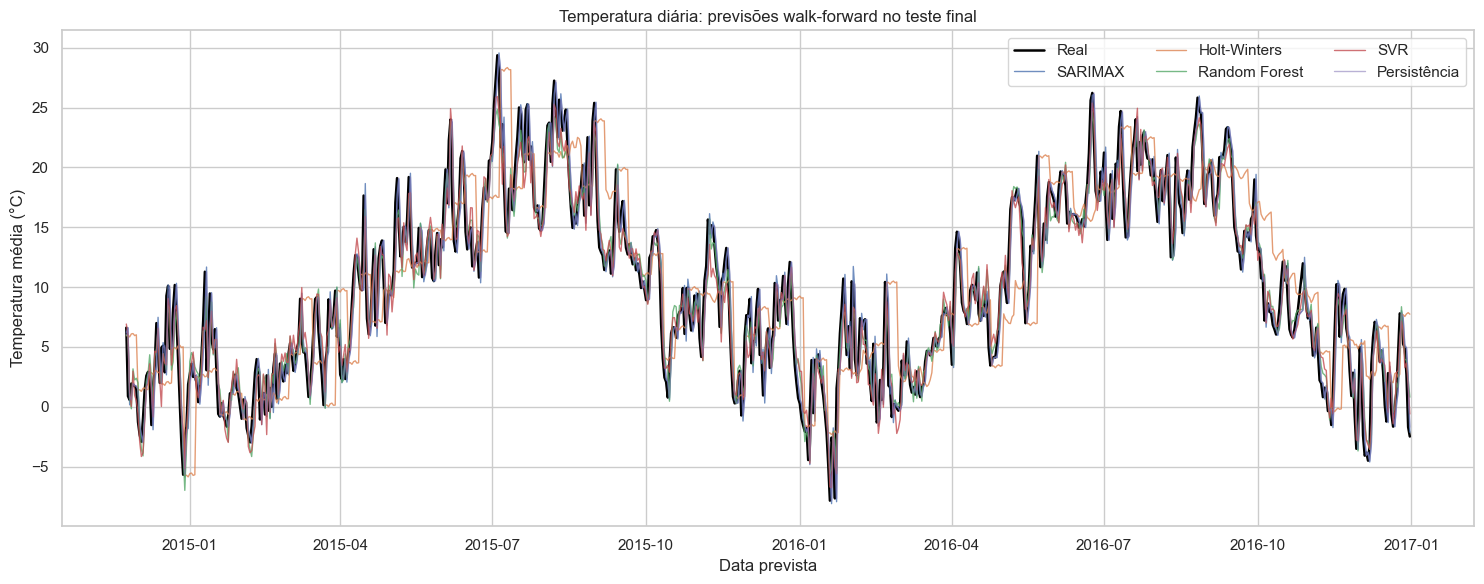

In [30]:
actual_values = y_test.to_numpy(dtype=float)
prediction_frames = []
metric_rows = []

parameters_by_model = {
    'SARIMAX': best_sarimax,
    'Holt-Winters': best_hw,
    'Random Forest': rf_grid.best_params_,
    'SVR': svr_grid.best_params_,
    'Persistência': {'regra': 'temperatura_t+1 = temperatura_t'},
}

for model_name, predicted_values in predictions_by_model.items():
    model_residuals = actual_values - predicted_values
    prediction_frames.append(pd.DataFrame({
        'base': BASE_ID,
        'modelo': model_name,
        'data_origem': origin_dates,
        'data_prevista': prediction_dates,
        'horizonte_dias': HORIZON,
        'valor_real_c': actual_values,
        'valor_previsto_c': predicted_values,
        'residuo_c': model_residuals,
    }))
    metric_rows.append({
        'base': BASE_ID,
        'modelo': model_name,
        'tipo': 'benchmark' if model_name == 'Persistência' else 'modelo',
        'mae_c': mean_absolute_error(actual_values, predicted_values),
        'rmse_c': np.sqrt(mean_squared_error(actual_values, predicted_values)),
        'vies_medio_c': float(np.mean(model_residuals)),
        'tempo_segundos': elapsed_by_model[model_name],
        'n_teste': TEST_SIZE,
        'horizonte_dias': HORIZON,
        'hiperparametros': repr(parameters_by_model[model_name]),
    })

predictions = pd.concat(prediction_frames, ignore_index=True)
metrics = pd.DataFrame(metric_rows).sort_values('mae_c', ignore_index=True)
metrics['rank_mae'] = metrics['mae_c'].rank(method='min').astype(int)
metrics['selecionado_na_validacao'] = metrics['modelo'].eq(selected_model)
display(metrics)

fig, ax = plt.subplots(figsize=(15, 6))
ax.plot(prediction_dates, actual_values, label='Real', color='black', linewidth=1.8)
for model_name, predicted_values in predictions_by_model.items():
    ax.plot(
        prediction_dates,
        predicted_values,
        label=model_name,
        alpha=0.80 if model_name != 'Persistência' else 0.55,
        linewidth=1.0,
    )
ax.set(
    title='Temperatura diária: previsões walk-forward no teste final',
    xlabel='Data prevista',
    ylabel='Temperatura média (°C)',
)
ax.legend(ncol=3)
fig.tight_layout()
fig.savefig(FIGURES_DIR / '03_previsoes.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Diagnóstico dos resíduos

A ACF mostra dependência temporal remanescente. O teste de Ljung-Box resume as dez primeiras defasagens: `p > 0,05` indica ausência de evidência suficiente de autocorrelação residual nesse intervalo.


,modelo,ljung_box_lag,ljung_box_stat,ljung_box_pvalue,residuos_brancos_5pct
0,SARIMAX,10,30.361228,7.474961e-04,False
1,Holt-Winters,10,760.818838,5.440776e-157,False
2,Random Forest,10,15.105236,1.282720e-01,True
3,SVR,10,18.025150,5.454087e-02,True
4,Persistência,10,50.689437,1.992629e-07,False


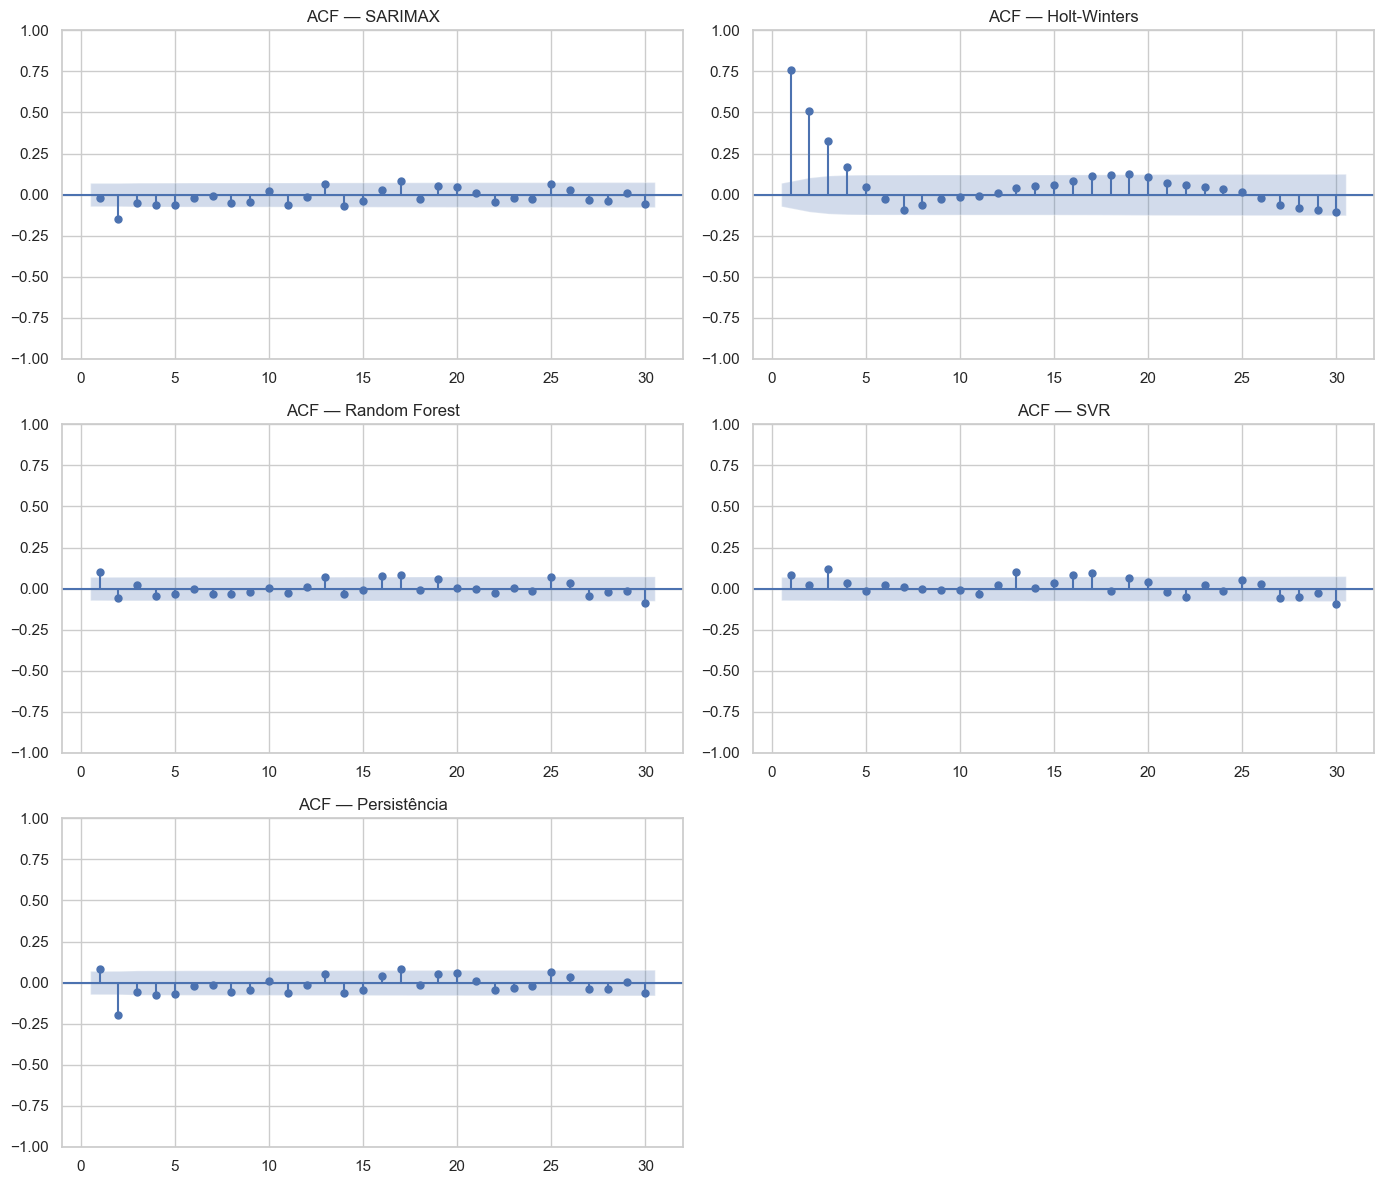

In [31]:
residual_frames = []
diagnostic_rows = []
n_models = len(predictions_by_model)
n_columns = 2
n_rows = int(np.ceil(n_models / n_columns))
fig, axes = plt.subplots(n_rows, n_columns, figsize=(14, 4 * n_rows))
axes = np.atleast_1d(axes).ravel()

for ax, (model_name, predicted_values) in zip(axes, predictions_by_model.items()):
    model_residuals = actual_values - predicted_values
    ljung_box = acorr_ljungbox(
        model_residuals,
        lags=[LJUNG_BOX_LAG],
        return_df=True,
    ).iloc[0]
    residuals_are_white = bool(ljung_box.lb_pvalue > 0.05)

    diagnostic_rows.append({
        'modelo': model_name,
        'ljung_box_lag': LJUNG_BOX_LAG,
        'ljung_box_stat': ljung_box.lb_stat,
        'ljung_box_pvalue': ljung_box.lb_pvalue,
        'residuos_brancos_5pct': residuals_are_white,
    })
    residual_frames.append(pd.DataFrame({
        'base': BASE_ID,
        'modelo': model_name,
        'data_prevista': prediction_dates,
        'residuo_c': model_residuals,
        'ljung_box_lag': LJUNG_BOX_LAG,
        'ljung_box_stat': ljung_box.lb_stat,
        'ljung_box_pvalue': ljung_box.lb_pvalue,
        'residuos_brancos_5pct': residuals_are_white,
    }))
    plot_acf(
        model_residuals,
        lags=min(30, TEST_SIZE // 3),
        zero=False,
        ax=ax,
        title=f'ACF — {model_name}',
    )

for unused_ax in axes[n_models:]:
    unused_ax.set_visible(False)

residuals = pd.concat(residual_frames, ignore_index=True)
diagnostics = pd.DataFrame(diagnostic_rows)
metrics = metrics.merge(diagnostics, on='modelo', how='left')
display(diagnostics)

fig.tight_layout()
fig.savefig(FIGURES_DIR / '04_acf_residuos.png', dpi=150, bbox_inches='tight')
plt.show()

## 12. Importância das variáveis

- SARIMAX e Holt-Winters: aumento do MAE após permutar valores históricos de temperatura em uma amostra das origens finais;
- Random Forest: redução de impureza acumulada;
- SVR: aumento do MAE após permutação no teste final.

A análise é diagnóstica e não participa da seleção dos modelos.


,base,modelo,feature,importance,importance_std,metodo,n_avaliacoes,janela_historica,rank
6,base_04,Holt-Winters,temperatura_hoje,1.685925,1.950574e-01,permutation_lag_delta_mae,8,365,1
9,base_04,Holt-Winters,temperatura_lag_7,0.006433,1.641353e-03,permutation_lag_delta_mae,8,365,2
7,base_04,Holt-Winters,temperatura_lag_1,0.000003,1.698409e-06,permutation_lag_delta_mae,8,365,3
11,base_04,Holt-Winters,temperatura_lag_30,0.000003,6.534717e-07,permutation_lag_delta_mae,8,365,4
8,base_04,Holt-Winters,temperatura_lag_2,-0.000003,1.843879e-07,permutation_lag_delta_mae,8,365,5
10,base_04,Holt-Winters,temperatura_lag_14,-0.027509,8.648463e-03,permutation_lag_delta_mae,8,365,6
12,base_04,Random Forest,temperatura_hoje,0.731750,0.000000e+00,impurity,1787,0,1
22,base_04,Random Forest,temperatura_media_7d,0.069890,0.000000e+00,impurity,1787,0,2
29,base_04,Random Forest,ponto_orvalho,0.046077,0.000000e+00,impurity,1787,0,3
13,base_04,Random Forest,temperatura_lag_1,0.043149,0.000000e+00,impurity,1787,0,4


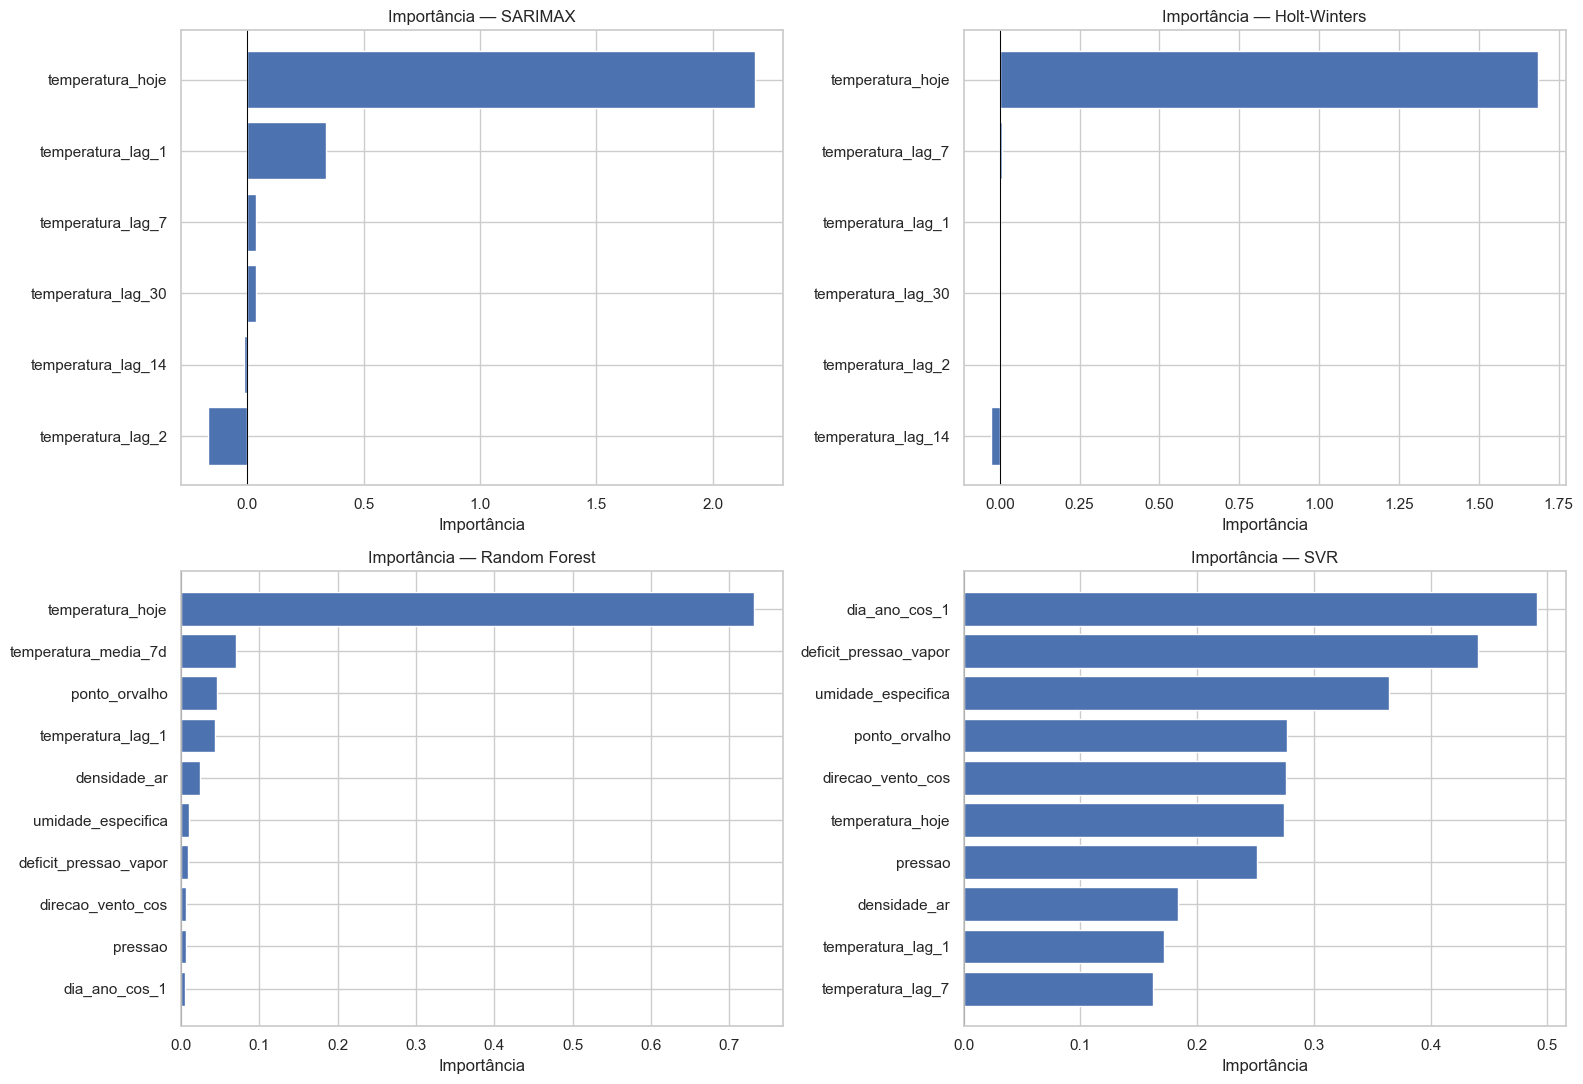

In [32]:
def classical_forecast(history, model_name):
    """Ajusta um modelo clássico em uma janela histórica e prevê um passo."""
    if model_name == 'SARIMAX':
        fitted_model = SARIMAX(
            history,
            **best_sarimax,
            enforce_stationarity=False,
            enforce_invertibility=False,
        ).fit(disp=False, maxiter=150)
    else:
        fitted_model = ExponentialSmoothing(
            history,
            **best_hw,
            seasonal_periods=MODEL_SEASONAL_PERIOD if best_hw['seasonal'] else None,
            initialization_method='estimated',
        ).fit(optimized=True, use_brute=False)
    return float(fitted_model.forecast(1).iloc[0])


def classical_lag_importance(model_name):
    """Mede quanto o MAE aumenta ao embaralhar pontos do histórico."""
    lag_map = {
        'temperatura_hoje': 1,
        'temperatura_lag_1': 2,
        'temperatura_lag_2': 3,
        'temperatura_lag_7': 8,
        'temperatura_lag_14': 15,
        'temperatura_lag_30': 31,
    }
    evaluation_dates = prediction_dates[-IMPORTANCE_EVAL_SIZE:]
    actual_evaluation_values = series.loc[evaluation_dates].to_numpy(dtype=float)
    histories = []

    for date in evaluation_dates:
        position = series.index.get_loc(date)
        window_start = max(0, position - IMPORTANCE_WINDOW)
        histories.append(series.iloc[window_start:position].copy())

    baseline_predictions = np.asarray([
        classical_forecast(history, model_name) for history in histories
    ])
    baseline_mae = mean_absolute_error(actual_evaluation_values, baseline_predictions)

    random_generator = np.random.default_rng(RANDOM_STATE)
    importance_rows = []
    for feature_name, position_from_end in lag_map.items():
        lag_values = np.asarray([
            history.iloc[-position_from_end] for history in histories
        ])
        mae_increases = []
        for _ in range(IMPORTANCE_REPEATS):
            shuffled_values = random_generator.permutation(lag_values)
            perturbed_predictions = []
            for history, replacement in zip(histories, shuffled_values):
                changed_history = history.copy()
                changed_history.iloc[-position_from_end] = replacement
                perturbed_predictions.append(
                    classical_forecast(changed_history, model_name)
                )
            perturbed_mae = mean_absolute_error(
                actual_evaluation_values,
                perturbed_predictions,
            )
            mae_increases.append(perturbed_mae - baseline_mae)

        importance_rows.append({
            'base': BASE_ID,
            'modelo': model_name,
            'feature': feature_name,
            'importance': float(np.mean(mae_increases)),
            'importance_std': float(np.std(mae_increases)),
            'metodo': 'permutation_lag_delta_mae',
            'n_avaliacoes': IMPORTANCE_EVAL_SIZE,
            'janela_historica': IMPORTANCE_WINDOW,
        })
    return pd.DataFrame(importance_rows)


sarimax_importance = classical_lag_importance('SARIMAX')
holt_winters_importance = classical_lag_importance('Holt-Winters')

rf_explainer = clone(rf_grid.best_estimator_).fit(
    X.iloc[:train_size], y_ml.iloc[:train_size]
)
rf_importance = pd.DataFrame({
    'base': BASE_ID,
    'modelo': 'Random Forest',
    'feature': feature_columns,
    'importance': rf_explainer.feature_importances_,
    'importance_std': 0.0,
    'metodo': 'impurity',
    'n_avaliacoes': train_size,
    'janela_historica': 0,
})

svr_explainer = clone(svr_grid.best_estimator_).fit(
    X.iloc[:train_size], y_ml.iloc[:train_size]
)
svr_permutation = permutation_importance(
    svr_explainer,
    X_test,
    y_test,
    scoring='neg_mean_absolute_error',
    n_repeats=5,
    random_state=RANDOM_STATE,
    n_jobs=1,
)
svr_importance = pd.DataFrame({
    'base': BASE_ID,
    'modelo': 'SVR',
    'feature': feature_columns,
    'importance': svr_permutation.importances_mean,
    'importance_std': svr_permutation.importances_std,
    'metodo': 'permutation_mae',
    'n_avaliacoes': len(X_test),
    'janela_historica': 0,
})

feature_importance = pd.concat(
    [sarimax_importance, holt_winters_importance, rf_importance, svr_importance],
    ignore_index=True,
)
feature_importance['rank'] = (
    feature_importance.groupby('modelo')['importance']
    .rank(ascending=False, method='min')
    .astype(int)
)

model_order = ['SARIMAX', 'Holt-Winters', 'Random Forest', 'SVR']
top_features = (
    feature_importance.sort_values(['modelo', 'rank'])
    .groupby('modelo', group_keys=False)
    .head(10)
)
display(top_features)

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
for ax, model_name in zip(axes.ravel(), model_order):
    model_features = (
        top_features[top_features['modelo'] == model_name]
        .sort_values('importance')
    )
    ax.barh(model_features['feature'], model_features['importance'])
    ax.axvline(0, color='black', linewidth=0.7)
    ax.set(title=f'Importância — {model_name}', xlabel='Importância')

fig.tight_layout()
fig.savefig(FIGURES_DIR / '05_importancia.png', dpi=150, bbox_inches='tight')
plt.show()

## 13. Exportação e validação dos artefatos

A etapa final salva a base diária, previsões, métricas do teste, métricas da janela de seleção, ajustes de hiperparâmetros, diagnóstico sazonal, resíduos, importâncias e figuras. As asserções verificam datas, quantidade de previsões, ausências, identidade do resíduo e registro de exatamente um modelo selecionado.


In [33]:
data.reset_index().to_csv(PROCESSED_PATH, index=False)
predictions.to_csv(PREDICTIONS_PATH, index=False)
metrics.to_csv(METRICS_PATH, index=False)
selection_metrics.to_csv(SELECTION_PATH, index=False)
sarimax_tuning.to_csv(SARIMAX_TUNING_PATH, index=False)
hw_tuning.to_csv(HW_TUNING_PATH, index=False)
seasonality_comparison.to_csv(SEASONALITY_PATH, index=False)
residuals.to_csv(RESIDUALS_PATH, index=False)
feature_importance.sort_values(['modelo', 'rank']).to_csv(
    IMPORTANCE_PATH,
    index=False,
)

expected_prediction_columns = {
    'base', 'modelo', 'data_origem', 'data_prevista', 'horizonte_dias',
    'valor_real_c', 'valor_previsto_c', 'residuo_c',
}
assert expected_prediction_columns.issubset(predictions.columns)
assert predictions.groupby('modelo').size().eq(TEST_SIZE).all()
assert not predictions[
    ['valor_real_c', 'valor_previsto_c', 'residuo_c']
].isna().any().any()
assert np.allclose(
    predictions['valor_real_c'] - predictions['valor_previsto_c'],
    predictions['residuo_c'],
)
assert predictions.groupby('modelo')['data_prevista'].apply(
    lambda values: values.is_monotonic_increasing
).all()
assert metrics['selecionado_na_validacao'].sum() == 1
assert metrics.loc[
    metrics['selecionado_na_validacao'], 'modelo'
].iloc[0] == selected_model

exported_paths = [
    PROCESSED_PATH,
    PREDICTIONS_PATH,
    METRICS_PATH,
    SELECTION_PATH,
    SARIMAX_TUNING_PATH,
    HW_TUNING_PATH,
    SEASONALITY_PATH,
    RESIDUALS_PATH,
    IMPORTANCE_PATH,
]
export_summary = pd.DataFrame({
    'arquivo': exported_paths,
    'existe': [path.exists() for path in exported_paths],
    'bytes': [path.stat().st_size if path.exists() else 0 for path in exported_paths],
})
display(export_summary)

selected_result = metrics.loc[metrics['modelo'] == selected_model].iloc[0]
best_test_result = metrics.iloc[0]
print(
    f'Selecionado na validação: {selected_result.modelo} | '
    f'MAE teste final = {selected_result.mae_c:.3f} °C | '
    f'RMSE teste final = {selected_result.rmse_c:.3f} °C'
)
print(
    f'Menor MAE observado no teste (comparativo): '
    f'{best_test_result.modelo} = {best_test_result.mae_c:.3f} °C'
)

,arquivo,existe,bytes
0,C:\Users\igorpereira-ieg\OneDrive - Instituto ...,True,900312
1,C:\Users\igorpereira-ieg\OneDrive - Instituto ...,True,380422
2,C:\Users\igorpereira-ieg\OneDrive - Instituto ...,True,1337
3,C:\Users\igorpereira-ieg\OneDrive - Instituto ...,True,323
4,C:\Users\igorpereira-ieg\OneDrive - Instituto ...,True,270
5,C:\Users\igorpereira-ieg\OneDrive - Instituto ...,True,223
6,C:\Users\igorpereira-ieg\OneDrive - Instituto ...,True,204
7,C:\Users\igorpereira-ieg\OneDrive - Instituto ...,True,377601
8,C:\Users\igorpereira-ieg\OneDrive - Instituto ...,True,8049


Selecionado na validação: SVR | MAE teste final = 1.647 °C | RMSE teste final = 2.085 °C
Menor MAE observado no teste (comparativo): SVR = 1.647 °C
